# GreenBite Market — Business Analysis with SQL

Analysis of sales, customers, products, employees, and branches using a relational database and SQL business queries.

**Tools:** MySQL · SQL · Jupyter Notebook

**Project type:** Business Analysis

**Database:** GreenBite Market

## 1. Project Overview

GreenBite Market is a fictional retail chain that sells groceries and everyday products across multiple branches.

The objective of this project is to analyze transactional data using SQL and answer business questions related to customers, products, sales, employees, and branch performance.

### Project Objectives

* Analyze transactional sales data.
* Understand customer purchasing behavior.
* Identify product and category performance.
* Compare branch performance.
* Explore employee sales activity.
* Practice relational SQL analysis.

### Analysis Approach

The analysis was structured around business questions rather than individual SQL features.

For each question, the required relationships between tables were identified, the appropriate level of aggregation was determined, and the resulting data was prepared for business analysis.

### Granularity

The level of aggregation was considered for each analysis to ensure that metrics such as number of purchases, product quantities, and total sales were calculated at the appropriate level.

## 2. Database Structure

### 2.1 Tables

| Table           | Description                    |
| --------------- | ------------------------------ |
| `branches`      | Store branches                 |
| `employees`     | Employees assigned to branches |
| `customers`     | Customers                      |
| `sales`         | Sales transactions             |
| `sales_details` | Products included in each sale |
| `products`      | Product catalog                |
| `categories`    | Product categories             |


### 2.2 Relationships

The database follows a relational structure where sales connect customers, employees, and branches, while `sales_details` connects each transaction with the products purchased.

```text
categories
    │
    └── products
             │
             └── sales_details
                       │
                       └── sales ─── customers
                              │
                              └── employees ─── branches
```

## 3. Notebook Setup

### Imports

In [2]:
import pandas as pd
import mysql.connector
import os

from dotenv import load_dotenv

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from IPython.display import Image

### Database Connection

The database connection is configured using environment variables stored in a `.env` file. This keeps database credentials outside the notebook and prevents sensitive information from being exposed in the project files.

In [3]:
load_dotenv()

connection = mysql.connector.connect(
    host=os.getenv("GREENBITE_DB_HOST"),
    port=os.getenv("GREENBITE_DB_PORT"),
    user=os.getenv("GREENBITE_DB_USER"),
    password=os.getenv("GREENBITE_DB_PASSWORD"),
    database=os.getenv("GREENBITE_DB_NAME")
)

Once the connection is established, the notebook proceeds to the business questions and analysis.

## 4. Business Questions

### Question 1 — Product Catalog

**Which products belong to each product category?**

**SQL query**

In [ ]:
SELECT p.product_id, p.product_name, c.category_name

FROM products as p
JOIN categories as c ON p.category_id = c.category_id;

**Query Result**

The following image shows the result returned by the SQL query.

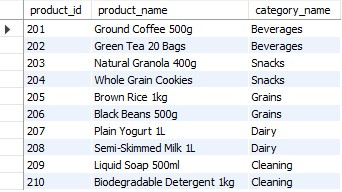

In [13]:
Image(filename='images/Result-Q1.jpg', width=500)


**Interpretation:**

GreenBite's product catalog contains 10 products distributed evenly across 5 categories, with 2 products in each category.

### Question 2 — Employees by Branch

**How are employees distributed across the different branches?**

**SQL Query**

In [ ]:
SELECT e.employee_id, e.name, e.lastname, b.branch_name, b.city

FROM employees as e
JOIN branches as b ON e.branch_id = b.branch_id;

**Query Result**

The following image shows the result returned by the SQL query.

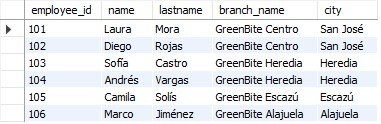

In [14]:
Image(filename='images/Result-Q2.jpg', width=500)

**Interpretation:**

The 6 employees are distributed across 4 branches. GreenBite Centro and GreenBite Heredia have 2 employees each, while GreenBite Escazú and GreenBite Alajuela have 1 employee each.

### Question 3 — Branches Without Employees

**Which employees are assigned to each branch, including branches with no employees?**

**SQL Query**

In [ ]:
SELECT b.branch_id, b.branch_name, e.name, e.lastname

FROM branches as b
LEFT JOIN employees as e ON b.branch_id = e.branch_id;

**Query Result**

The following image shows the result returned by the SQL query.

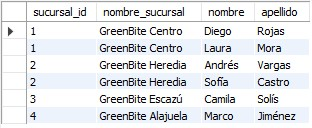

In [ ]:
Image(filename='images/Result-Q3.jpg', width=500)

**Interpretation:**

All four branches currently have at least one assigned employee. The LEFT JOIN ensures that branches would still appear in the results even if they had no employees assigned.

### Question 4 — Sales Context

**Which customer, employee, and branch are associated with each sale?**

**SQL Query**

In [ ]:
SELECT s.sale_id, c.customer_name, e.employee_id, e.name, e.lastname, b.branch_name

FROM sales as s
LEFT JOIN customers as c ON s.customer_id = c.customer_id
LEFT JOIN employees as e ON s.employee_id = e.employee_id
LEFT JOIN branches as b ON s.branch_id = b.branch_id;

**Query Result**

The following image shows the result returned by the SQL query.

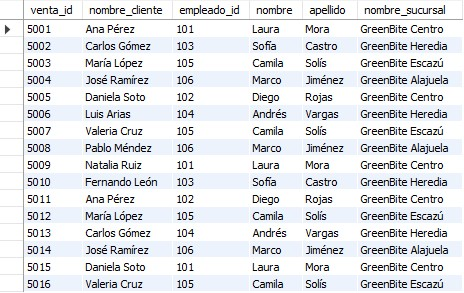

In [ ]:
Image(filename='images/Result-Q4.jpg', width=500)

**Interpretation:**

Each sale can be associated with a customer, employee, and branch, providing the relational context needed for further sales analysis.

### Question 5 — Customer Lookup

**What information is associated with a specific customer ID?**

**SQL Query**

In [ ]:
SELECT *
FROM clientes
WHERE cliente_id = 1007;

**Query Result**

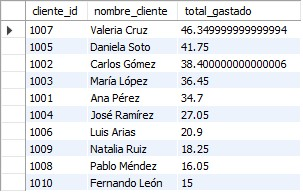

In [ ]:
Image(filename='images/Result-Q5.jpg', width=500)

**Interpretation:**

Customer ID 1007 corresponds to Valeria Cruz, who is associated with the Escazú branch.

### Question 6 — Customer Purchasing Behavior

**How much does each customer spend, and how many purchases do they make?**

**SQL Query**

In [ ]:
SELECT c.customer_id, c.customer_name, 
TRUNCATE(SUM(p.unit_price * sd.quantity), 2)AS total_spent,
COUNT(DISTINCT s.sale_id) AS purchase_count

FROM customers as c
JOIN sales as s ON c.customer_id = s.customer_id
JOIN sales_details as sd ON s.sale_id = sd.sale_id
JOIN products as p ON sd.product_id = p.product_id

GROUP BY c.customer_id, c.customer_name
ORDER BY total_spent DESC;

**Query Result**

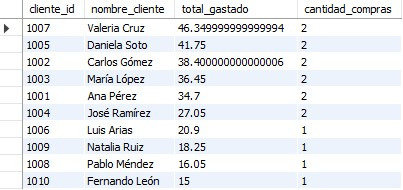

In [ ]:
Image(filename='images/Result-Q6.jpg', width=500)

**Interpretation:**

Valeria Cruz has the highest total spending at $46.34 across 2 purchases. The results also show that customers with the same number of purchases can have different total spending, depending on the value of their transactions.

### Question 7 — Product Units Sold

**Which products have sold the highest number of units?**

**SQL Query**

In [ ]:
SELECT p.product_id, p.product_name, SUM(sd.quantity) AS quantity_total

FROM sales as s 
JOIN sales_details as sd ON s.sale_id = sd.sale_id
JOIN products as p ON sd.product_id = p.product_id

GROUP BY p.product_id, p.product_name
ORDER BY quantity_total DESC, p.product_id DESC;

**Query Result**

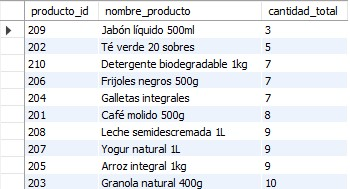

In [ ]:
Image(filename='images/Result-Q7.jpg', width=500)

**Interpretation:**

Natural Granola 400g has the highest sales volume with 10 units sold. Brown Rice 1kg, Plain Yogurt 1L, and Semi-Skimmed Milk 1L follow with 9 units each.

### Question 8 — Category Revenue

**Which product categories generate the highest sales revenue?**

This analysis identifies the product categories that generate the highest sales revenue by calculating total revenue for each category.

The revenue is calculated by multiplying the unit price of each product by the quantity sold, then aggregating the results by product category.

The query returns the top four categories, ordered from highest to lowest total sales revenue.

**SQL Query**

In [ ]:
SELECT c.category_id, c.category_name, 
TRUNCATE(SUM(p.unit_price * sd.quantity), 2) as total_sales

FROM sales_details as sd   
JOIN products as p ON sd.product_id = p.product_id
JOIN categories as c ON p.category_id = c.category_id

GROUP BY c.category_id, c.category_name
ORDER BY total_sales DESC;

**Query Result**

The following image shows the result returned by the SQL query.

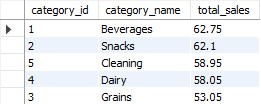

In [4]:
Image(filename='images/Result-Q8.jpg', width=500)

#### **Visualization**

The query result is loaded into a Pandas DataFrame and used to create a horizontal bar chart.

The chart displays the four categories with the highest sales revenue, making it easier to compare their relative contribution to total revenue.

In [4]:
df_category_sales = pd.read_sql(
"""
SELECT c.category_id, c.category_name, 
TRUNCATE(SUM(p.unit_price * sd.quantity), 2) as total_sales

FROM sales_details as sd   
JOIN products as p ON sd.product_id = p.product_id
JOIN categories as c ON p.category_id = c.category_id

GROUP BY c.category_id, c.category_name
ORDER BY total_sales DESC
LIMIT 4;
""", connection
)

C:\Users\dani0_i3bo1z5\AppData\Local\Temp\ipykernel_13052\3976265646.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_category_sales = pd.read_sql(


In [5]:
# Verifying the query before creating the chart
df_category_sales

,category_id,category_name,total_sales
0,1,Beverages,62.75
1,2,Snacks,62.10
2,5,Cleaning,58.95
3,4,Dairy,58.05


The categories are sorted in ascending order so the highest-revenue category appears at the top of the horizontal bar chart.

In [6]:
df_plot = df_category_sales.sort_values( 
    by="total_sales", 
    ascending=True 
    )

The visualization uses the GreenBite color palette and formats revenue values as currency.

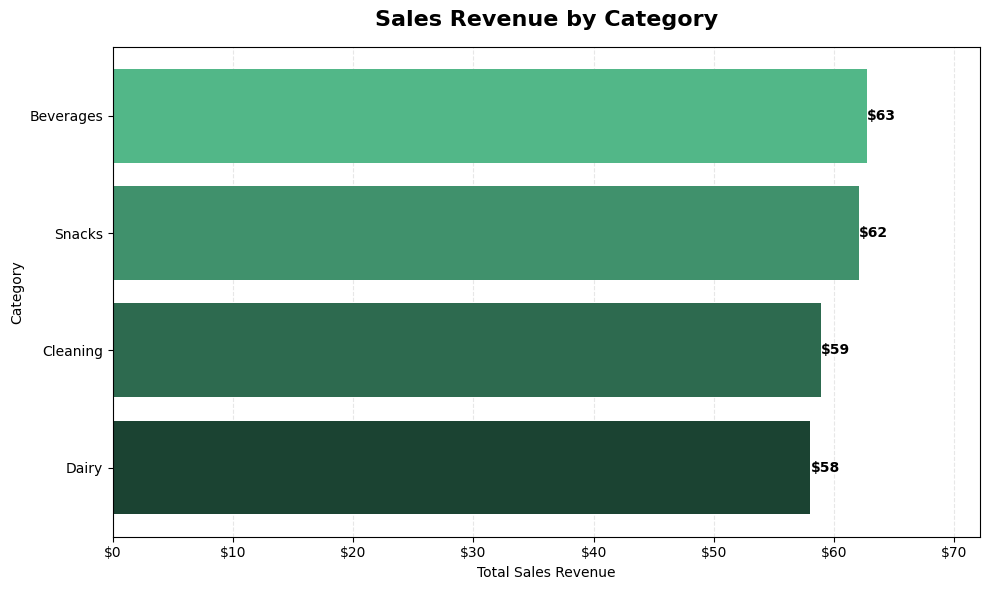

In [7]:
# GreenBite palette
greenbite_palette = [
    "#1B4332",
    "#2D6A4F",
    "#40916C",
    "#52B788",
    "#74C69D"
]

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_plot["category_name"],
    df_plot["total_sales"],
    color=greenbite_palette[:len(df_plot)]
)

ax.set_title(
    "Sales Revenue by Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Total Sales Revenue")
ax.set_ylabel("Category")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

ax.set_xlim(
    0,
    df_plot["total_sales"].max() * 1.15
)

plt.tight_layout()
plt.show()


**Interpretation:**

Beverages generated the highest sales revenue at $62.75, followed closely by Snacks at $62.10. Grains generated the lowest revenue among the five categories at $53.05.

### Question 9 — Sales by Branch

**How does total sales revenue compare across branches?**

This analysis compares the total sales revenue generated by each branch.

Revenue is calculated by multiplying the unit price of each product by the quantity sold, then aggregating the results by branch.

The branches are ordered from highest to lowest total sales revenue to facilitate comparison.

**SQL Query**

In [ ]:
SELECT b.branch_id, b.branch_name, 
TRUNCATE(SUM(p.unit_price * sd.quantity), 2) AS total_sales

FROM sales as s
JOIN branches as b ON s.branch_id = b.branch_id
JOIN sales_details as sd ON s.sale_id = sd.sale_id
JOIN products as p ON sd.product_id = p.product_id

GROUP BY b.branch_id, b.branch_name
ORDER BY total_sales DESC
;

**Query Result**

The following image shows the result returned by the SQL query.

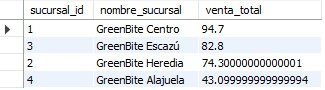

In [ ]:
Image(filename='images/Result-Q9.jpg', width=500)

#### **Visualization**

The query result is loaded into a Pandas DataFrame and used to create a horizontal bar chart.

The chart compares total sales revenue across branches, with the highest-revenue branch displayed at the top.

In [ ]:
df_branch_sales = pd.read_sql(
"""
SELECT b.branch_id, b.branch_name, 
TRUNCATE(SUM(p.unit_price * sd.quantity), 2) AS total_sales

FROM sales as s
JOIN branches as b ON s.branch_id = b.branch_id
JOIN sales_details as sd ON s.sale_id = sd.sale_id
JOIN products as p ON sd.product_id = p.product_id

GROUP BY b.branch_id, b.branch_name
ORDER BY total_sales DESC
;
""",
    connection
)

C:\Users\dani0_i3bo1z5\AppData\Local\Temp\ipykernel_7772\688749364.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_branch_sales = pd.read_sql(


In [ ]:
# Verifying the query before creating the chart
df_branch_sales

,sucursal_id,nombre_sucursal,venta_total
0,1,GreenBite Centro,94.7
1,3,GreenBite Escazú,82.8
2,2,GreenBite Heredia,74.3
3,4,GreenBite Alajuela,43.1


The branches are sorted in ascending order before plotting so that the highest-revenue branch appears at the top of the horizontal bar chart.

In [ ]:
df_plot = df_branch_sales.sort_values(
    by="total_sales",
    ascending=True
)

The visualization uses the GreenBite color palette and formats revenue values as currency.

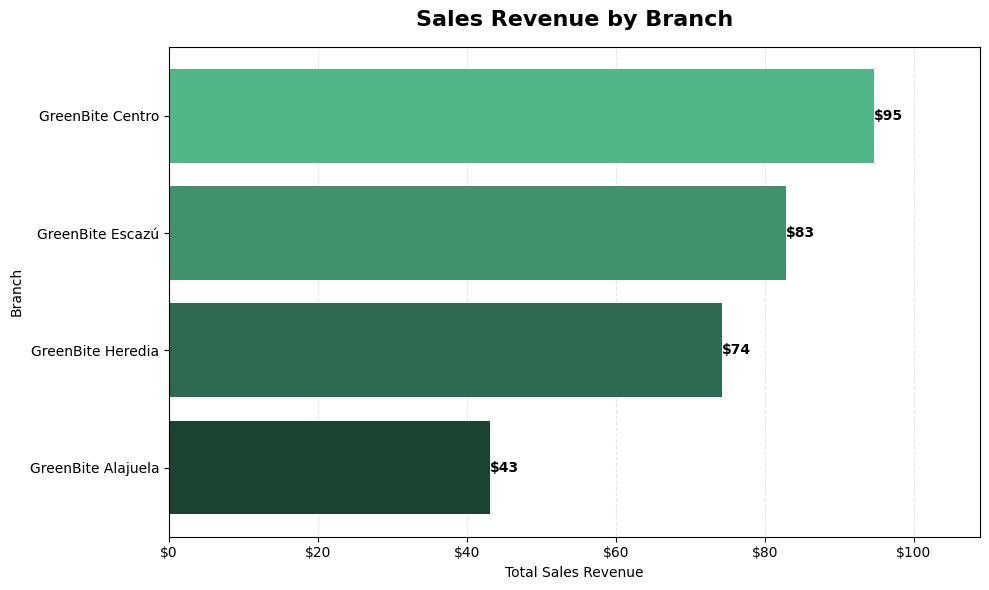

In [ ]:
# GreenBite palette
greenbite_palette = [
    "#1B4332",
    "#2D6A4F",
    "#40916C",
    "#52B788",
    "#74C69D"
]

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_plot["branch_name"],
    df_plot["total_sales"],
    color=greenbite_palette[:len(df_plot)]
)

ax.set_title(
    "Sales Revenue by Branch",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Total Sales Revenue")
ax.set_ylabel("Branch")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

ax.set_xlim(
    0,
    df_plot["total_sales"].max() * 1.15
)

plt.tight_layout()
plt.show()

**Interpretation:**

GreenBite Centro generated the highest sales revenue at $94.70, while GreenBite Alajuela generated the lowest at $43.09. The results show differences in branch revenue but do not establish the reasons behind those differences.

### Question 10 — Average Purchase Value

**What is the average value of a customer purchase?**

This analysis calculates the average purchase value for each customer.

Because a single sale can contain multiple products, the analysis is performed in two steps:

Calculate the total value of each individual sale for each customer.
Calculate the average of those sale totals for each customer.

This approach ensures that the average is calculated at the sale level, rather than at the individual product-line level.

**SQL Query**

In [ ]:
WITH customer_purchase AS (
	SELECT
		c.customer_id, c.customer_name, s.sale_id,
        SUM(p.unit_price * sd.quantity) AS total_sales
	FROM sales as s
	JOIN customers as c ON s.customer_id = c.customer_id
	JOIN sales_details as sd ON s.sale_id = sd.sale_id
	JOIN products as p ON sd.product_id = p.product_id
    
	GROUP BY c.customer_id, c.customer_name, s.sale_id
    )

SELECT customer_id, customer_name, TRUNCATE(
AVG(total_sales), 2) as average_purchase_value

FROM customer_purchase 

GROUP BY customer_id, customer_name
ORDER BY customer_id DESC;

**Query Result**

The following image shows the result returned by the SQL query.

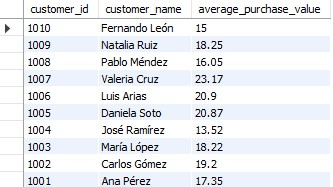

In [8]:
from IPython.display import Image
Image(filename='images/Result-Q10.jpg', width=500)

#### **Visualization**

The query result is loaded into a Pandas DataFrame and used to create a horizontal bar chart.

The chart compares the average purchase value across customers, with the highest average purchase value displayed at the top.

In [9]:
average_purchase_value = pd.read_sql(
"""
WITH customer_purchase AS (
	SELECT
		c.customer_id, c.customer_name, s.sale_id,
        SUM(p.unit_price * sd.quantity) AS total_sales
	FROM sales as s
	JOIN customers as c ON s.customer_id = c.customer_id
	JOIN sales_details as sd ON s.sale_id = sd.sale_id
	JOIN products as p ON sd.product_id = p.product_id
    
	GROUP BY c.customer_id, c.customer_name, s.sale_id
    )

SELECT customer_id, customer_name, TRUNCATE(
AVG(total_sales), 2) as average_purchase_value

FROM customer_purchase 

GROUP BY customer_id, customer_name
ORDER BY customer_id DESC;
""",
    connection
)

C:\Users\dani0_i3bo1z5\AppData\Local\Temp\ipykernel_13052\272292072.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  average_purchase_value = pd.read_sql(


In [10]:
# Verifying the query result before creating the visualization
average_purchase_value

,customer_id,customer_name,average_purchase_value
0,1010,Fernando León,15.00
1,1009,Natalia Ruiz,18.25
2,1008,Pablo Méndez,16.05
3,1007,Valeria Cruz,23.17
4,1006,Luis Arias,20.90
5,1005,Daniela Soto,20.87
6,1004,José Ramírez,13.52
7,1003,María López,18.22
8,1002,Carlos Gómez,19.20
9,1001,Ana Pérez,17.35


The customers are sorted in ascending order before plotting so that the customer with the highest average purchase value appears at the top of the horizontal bar chart.

In [11]:
df_plot = average_purchase_value.sort_values(
    by="average_purchase_value",
    ascending=True
)

The visualization uses the GreenBite color palette and formats revenue values as currency.

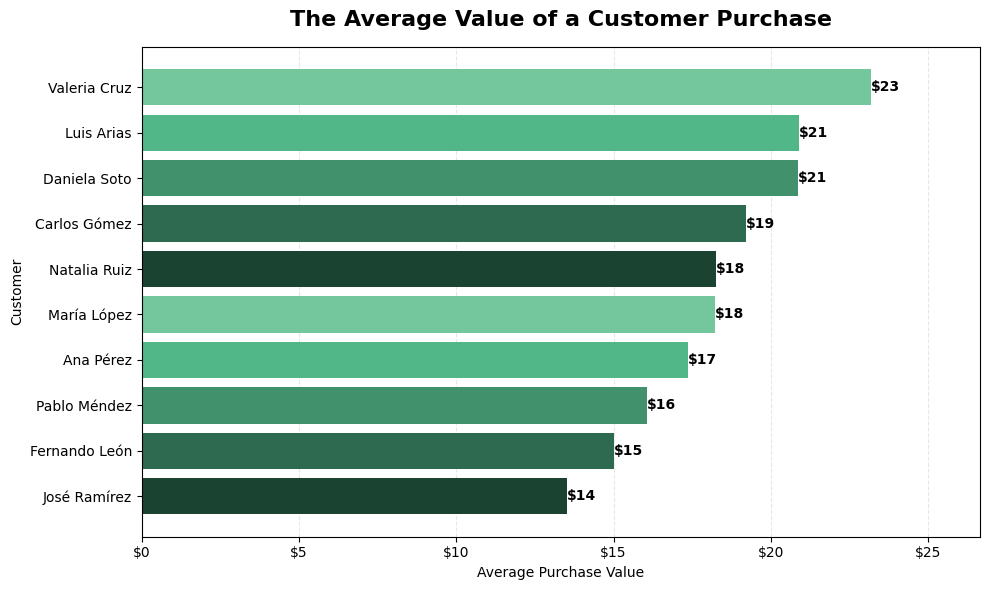

In [ ]:
# GreenBite palette
greenbite_palette = [
    "#1B4332",
    "#2D6A4F",
    "#40916C",
    "#52B788",
    "#74C69D"
]

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_plot["customer_name"],
    df_plot["average_purchase_value"],
    color=greenbite_palette[:len(df_plot)]
)

ax.set_title(
    "The Average Value of a Customer Purchase",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Average Purchase Value")
ax.set_ylabel("Customer")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

ax.set_xlim(
    0,
    df_plot["average_purchase_value"].max() * 1.15
)

plt.tight_layout()
plt.show()

**Interpretation:**

Valeria Cruz has the highest average purchase value at $23.17 per transaction. Her average is based on 2 purchases, while the remaining customers show different average transaction values based on their individual purchase history.

## 5. Business Findings

### Key Findings

#### Customer Behavior

* **Valeria Cruz recorded the highest total spending**, with $46.34 across 2 purchases.
* Valeria Cruz also had the **highest average purchase value**, at $23.17 per transaction.
* Six customers made 2 purchases, while four customers made 1 purchase during the analyzed period.
* Total spending varied among customers with the same number of purchases, showing that purchase frequency alone does not determine total customer spending.

#### Product Performance

* **Natural Granola 400g had the highest sales volume**, with 10 units sold.
* Brown Rice 1kg, Plain Yogurt 1L, and Semi-Skimmed Milk 1L each recorded 9 units sold.
* Liquid Soap 500ml had the lowest sales volume, with 3 units sold.
* The product with the highest number of units sold is not necessarily the product generating the highest revenue, since revenue also depends on unit price.

#### Category Performance

* **Beverages generated the highest sales revenue**, with $62.75.
* Snacks followed closely with $62.10, a difference of only $0.65 compared with Beverages.
* Cleaning generated $58.95, while Dairy generated $58.05.
* Grains recorded the lowest category revenue, with $53.05.

#### Branch Performance

* **GreenBite Centro generated the highest sales revenue**, with $94.70.
* GreenBite Escazú followed with $82.80, while GreenBite Heredia generated $74.30.
* GreenBite Alajuela recorded the lowest sales revenue, with $43.09.
* The employee distribution varies across branches, with Centro and Heredia having 2 employees each and Escazú and Alajuela having 1 employee each.


## 6. SQL Skills Demonstrated

This project demonstrates the following SQL concepts and analytical techniques:

* Relational database analysis
* Primary key and foreign key relationships
* INNER JOIN
* LEFT JOIN
* Multiple-table joins
* Table aliases
* GROUP BY
* Aggregate functions
* SUM()
* COUNT()
* COUNT(DISTINCT)
* Common Table Expressions (CTEs)
* ORDER BY
* LIMIT
* WHERE filtering
* Calculated metrics
* Result-set granularity
* Business-oriented metrics
* Multi-level aggregation
* Translating business questions into SQL queries


## 7. Conclusion

The analysis provides an overview of GreenBite Market's customers, products, employees, and branches using transactional sales data. The results show differences in customer spending, product volume, category revenue, branch revenue, and average purchase value.

Valeria Cruz recorded the highest total spending and the highest average purchase value among the analyzed customers, while Natural Granola 400g had the highest number of units sold. At the category level, Beverages generated the highest sales revenue, and GreenBite Centro recorded the highest branch revenue.

Overall, the project demonstrates how relational SQL queries can transform transactional data into business-oriented metrics and support the analysis of customer, product, and branch performance.

## 8. Reproducibility

[Database setup](../sql/database_setup.sql)

[Data insertion](../sql/data_insertion.sql)

[Business analysis](../sql/business_analysis.sql)